# Exploratory Data Analysis - Trentino Airbnb (Multi-Period)

**Research Question:** What are the significant spatial and structural factors affecting Airbnb prices in Trentino across different seasons?

**Dataset:** `trentino_listings_maps.csv` — Listings from 4 periods (december, june, march, september) with structural, reputational, locational, and host variables.

**Workflow:**
1. Load and validate data
2. Descriptive statistics (price, structural, host variables)
3. Period comparison (seasonal patterns)
4. New variables analysis (bedrooms, bathrooms, ratings, superhost)
5. Spatial distribution analysis
6. Correlation analysis
7. Summary for R spatial regression

---

In [29]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

In [30]:
# Load dataset
df = pd.read_csv('../datasets/trentino_listings_maps.csv')

print(f"Dataset shape: {df.shape}")
print(f"Total listings: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Dataset shape: (11904, 32)
Total listings: 11904
Columns: ['id', 'price', 'log_price', 'price_per_person', 'room_type', 'property_type', 'accommodates', 'bedrooms', 'beds', 'bathrooms', 'n_reviews', 'review_scores_rating', 'host_is_superhost', 'availability_365', 'minimum_nights', 'period', 'municipality', 'cod_istat', 'dist_ski', 'dist_lake', 'dist_park', 'dist_station', 'dist_bus', 'dist_center', 'dist_supermarket', 'dist_restaurant', 'dist_bar', 'dist_pharmacy', 'dist_castle', 'dist_museum', 'lat', 'long']


,id,price,log_price,price_per_person,room_type,property_type,accommodates,bedrooms,beds,bathrooms,...,dist_bus,dist_center,dist_supermarket,dist_restaurant,dist_bar,dist_pharmacy,dist_castle,dist_museum,lat,long
0,37736,159.0,5.068904,39.750000,Entire home/apt,Entire rental unit,4,1.0,1.0,2.0,...,686.767246,2591.787722,524.004548,553.292304,2104.594325,2536.900966,1050.191549,2616.353812,46.43561,11.10380
1,56292,279.0,5.631212,69.750000,Entire home/apt,Entire rental unit,4,1.0,2.0,1.0,...,82.009647,2707.498230,51.408723,12.317323,92.799034,149.867838,10904.720696,426.200814,46.23199,10.82732
2,249351,72.0,4.276666,9.000000,Private room,Private room in bed and breakfast,8,3.0,8.0,3.0,...,292.436933,1724.222204,211.209375,743.675731,996.357885,1089.186247,2321.903886,822.894852,46.36155,10.91591
3,299464,147.0,4.990433,49.000000,Entire home/apt,Entire condo,3,0.0,2.0,1.0,...,140.277109,2941.780487,431.125220,364.812817,508.836574,1027.261858,1342.109137,2551.487432,45.90883,10.84660
4,367596,95.0,4.553877,15.833333,Entire home/apt,Entire rental unit,6,2.0,5.0,1.0,...,96.759867,7411.744320,171.667295,244.260865,48.792808,258.493818,13605.301548,1343.910473,46.15799,10.76669


In [31]:
# Data types and info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11904 entries, 0 to 11903
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    11904 non-null  int64  
 1   price                 11904 non-null  float64
 2   log_price             11904 non-null  float64
 3   price_per_person      11904 non-null  float64
 4   room_type             11904 non-null  str    
 5   property_type         11904 non-null  str    
 6   accommodates          11904 non-null  int64  
 7   bedrooms              11904 non-null  float64
 8   beds                  11904 non-null  float64
 9   bathrooms             11904 non-null  float64
 10  n_reviews             11904 non-null  int64  
 11  review_scores_rating  11904 non-null  float64
 12  host_is_superhost     11904 non-null  float64
 13  availability_365      11904 non-null  int64  
 14  minimum_nights        11904 non-null  int64  
 15  period                11904 no

In [32]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:
    print("⚠️ Missing values found:")
    for col, count in missing.items():
        print(f"  {col}: {count} ({count/len(df)*100:.1f}%)")
else:
    print("✅ No missing values!")

✅ No missing values!


In [33]:
# Check for extreme outliers in distances (99999 = dummy values from failed OSM downloads)
distance_cols = [col for col in df.columns if col.startswith('dist_')]

print("Distance columns with dummy values (99999):")
found_dummy = False
for col in distance_cols:
    dummy_count = (df[col] == 99999).sum()
    if dummy_count > 0:
        print(f"  {col}: {dummy_count} listings ({dummy_count/len(df)*100:.1f}%)")
        found_dummy = True
if not found_dummy:
    print("  ✅ No dummy values found in any distance column")

Distance columns with dummy values (99999):
  ✅ No dummy values found in any distance column


## 2. Descriptive Statistics — Price

=== PRICE STATISTICS ===
              price     log_price
count  11904.000000  11904.000000
mean     157.129284      4.873918
std      127.756775      0.558910
min       10.000000      2.302585
25%       90.000000      4.499810
50%      123.000000      4.812184
75%      177.000000      5.176150
max     1999.000000      7.600402

Median price: $123.00
Price range: $10.00 - $1999.00


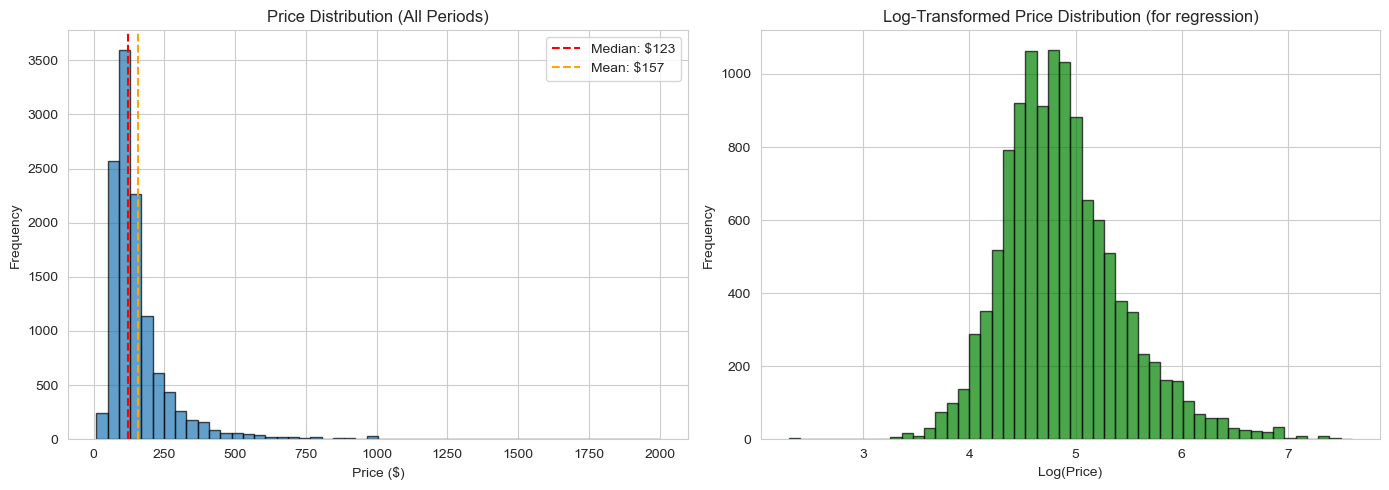

In [34]:
# Price distribution
print("=== PRICE STATISTICS ===")
print(df[['price', 'log_price']].describe())

print(f"\nMedian price: ${df['price'].median():.2f}")
print(f"Price range: ${df['price'].min():.2f} - ${df['price'].max():.2f}")

# Price distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df['price'].median(), color='red', linestyle='--', label=f'Median: ${df["price"].median():.0f}')
axes[0].axvline(df['price'].mean(), color='orange', linestyle='--', label=f'Mean: ${df["price"].mean():.0f}')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Price Distribution (All Periods)')
axes[0].legend()

axes[1].hist(df['log_price'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Log(Price)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Log-Transformed Price Distribution (for regression)')

plt.tight_layout()
plt.show()

In [35]:
# Room type distribution
print("=== ROOM TYPE DISTRIBUTION ===")
room_counts = df['room_type'].value_counts()
print(room_counts)
print(f"\nPercentages:")
print((room_counts / len(df) * 100).round(1))

# Property type distribution (NEW)
print("\n=== PROPERTY TYPE DISTRIBUTION (Top 15) ===")
prop_counts = df['property_type'].value_counts().head(15)
print(prop_counts)
print(f"\nTotal unique property types: {df['property_type'].nunique()}")

=== ROOM TYPE DISTRIBUTION ===
room_type
Entire home/apt    10630
Private room        1244
Hotel room            28
Shared room            2
Name: count, dtype: int64

Percentages:
room_type
Entire home/apt    89.3
Private room       10.5
Hotel room          0.2
Shared room         0.0
Name: count, dtype: float64

=== PROPERTY TYPE DISTRIBUTION (Top 15) ===
property_type
Entire rental unit                   7037
Entire condo                         1840
Entire home                           562
Private room in bed and breakfast     552
Entire vacation home                  361
Entire cabin                          304
Private room in rental unit           230
Entire chalet                         121
Private room in home                  110
Entire villa                          103
Room in hotel                          80
Private room in farm stay              75
Private room in condo                  72
Entire loft                            69
Entire serviced apartment             

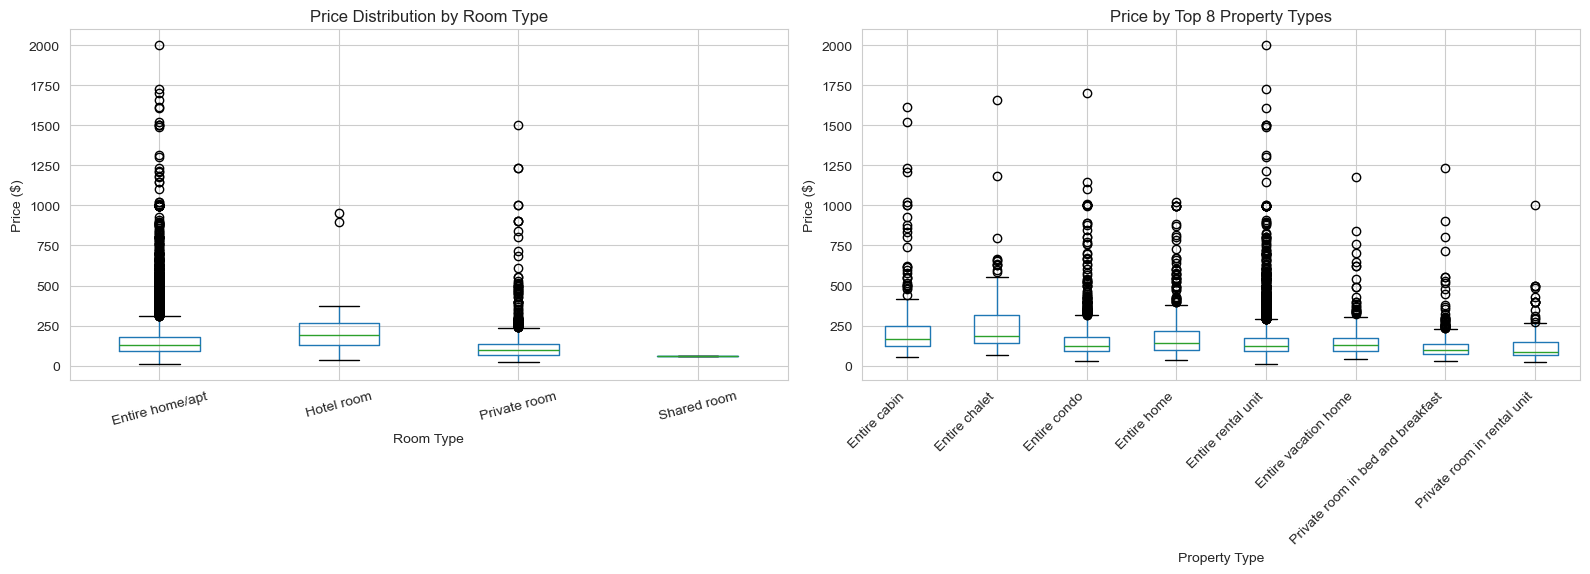


Mean price by room type:
                   mean  median  count
room_type                             
Entire home/apt  160.81   126.0  10630
Hotel room       241.93   191.0     28
Private room     123.94    95.0   1244
Shared room       59.00    59.0      2


In [37]:
# Price by room type
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df.boxplot(column='price', by='room_type', ax=axes[0])
axes[0].set_xlabel('Room Type')
axes[0].set_ylabel('Price ($)')
axes[0].set_title('Price Distribution by Room Type')
axes[0].figure.suptitle('')
axes[0].tick_params(axis='x', rotation=15)

# Price by top property types
top_props = df['property_type'].value_counts().head(8).index
df_top_props = df[df['property_type'].isin(top_props)]
df_top_props.boxplot(column='price', by='property_type', ax=axes[1])
axes[1].set_xlabel('Property Type')
axes[1].set_ylabel('Price ($)')
axes[1].set_title('Price by Top 8 Property Types')
axes[1].figure.suptitle('')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\nMean price by room type:")
print(df.groupby('room_type')['price'].agg(['mean', 'median', 'count']).round(2))

In [ ]:
# Accommodates distribution
print("=== ACCOMMODATES STATISTICS ===")
print(df['accommodates'].describe())
print(f"\nMost common capacity: {df['accommodates'].mode()[0]} guests")

# Top municipalities
print("\n=== TOP 15 MUNICIPALITIES BY NUMBER OF LISTINGS ===")
top_municipalities = df['municipality'].value_counts().head(15)
print(top_municipalities)

=== ACCOMMODATES STATISTICS ===
count    11904.000000
mean         4.530410
std          1.872411
min          1.000000
25%          4.000000
50%          4.000000
75%          6.000000
max         16.000000
Name: accommodates, dtype: float64

Most common capacity: 4 guests

=== TOP 15 MUNICIPALITIES BY NUMBER OF LISTINGS ===
municipality
Riva del Garda                       1150
Trento                                780
Arco                                  730
Pinzolo                               493
Ledro                                 475
Nago-Torbole                          385
San Giovanni di Fassa-Sèn Jan         374
Canazei                               374
Campitello di Fassa                   242
Dimaro Folgarida                      225
Mezzana                               218
Primiero San Martino di Castrozza     214
Rovereto                              202
Moena                                 201
Predazzo                              186
Name: count, dtype: int64


## 3. Period Comparison (Seasonal Patterns)

Compare listing counts, prices, and characteristics across the four scraping periods.

In [ ]:
# Period distribution
print("=== LISTINGS PER PERIOD ===")
period_counts = df['period'].value_counts()
print(period_counts)

# Order periods chronologically
period_order = ['march', 'june', 'september', 'december']
periods_present = [p for p in period_order if p in df['period'].unique()]

# Summary statistics by period
print("\n=== PRICE STATISTICS BY PERIOD ===")
period_stats = df.groupby('period')['price'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(2)
period_stats = period_stats.reindex(periods_present)
print(period_stats)

=== LISTINGS PER PERIOD ===
period
september    6194
december     5710
Name: count, dtype: int64

=== PRICE STATISTICS BY PERIOD ===
           count    mean  median     std   min     max
period                                                
september   6194  136.68   111.0  109.02  10.0  1999.0
december    5710  179.31   140.0  142.09  10.0  1724.0


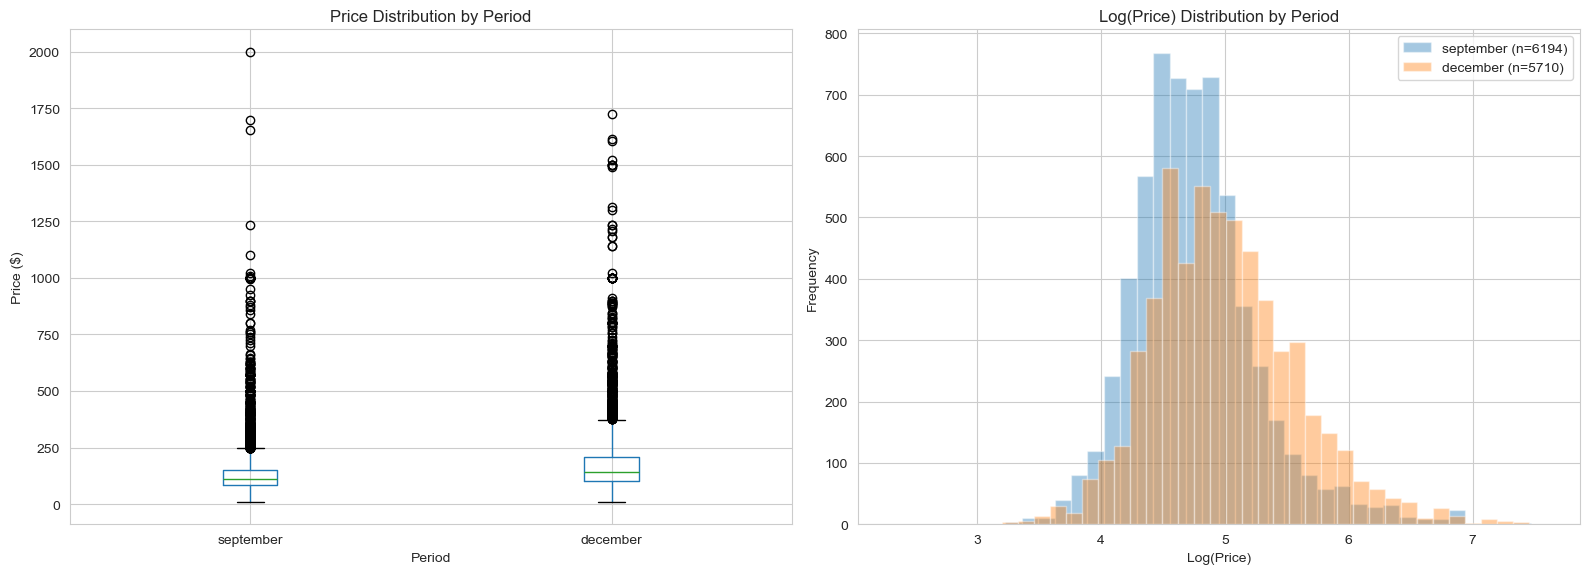

In [ ]:
# Price distribution by period
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
df_ordered = df.copy()
df_ordered['period'] = pd.Categorical(df_ordered['period'], categories=periods_present, ordered=True)

df_ordered.boxplot(column='price', by='period', ax=axes[0])
axes[0].set_xlabel('Period')
axes[0].set_ylabel('Price ($)')
axes[0].set_title('Price Distribution by Period')
axes[0].figure.suptitle('')

# Overlapping histograms of log_price
for period in periods_present:
    data = df[df['period'] == period]['log_price']
    axes[1].hist(data, bins=40, alpha=0.4, label=f'{period} (n={len(data)})')
axes[1].set_xlabel('Log(Price)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Log(Price) Distribution by Period')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Room type distribution by period
print("=== ROOM TYPE DISTRIBUTION BY PERIOD ===")
room_period = pd.crosstab(df['period'], df['room_type'], normalize='index').round(3) * 100
room_period = room_period.reindex(periods_present)
print(room_period)

# Superhost ratio by period
print("\n=== SUPERHOST RATIO BY PERIOD ===")
superhost_period = df.groupby('period')['host_is_superhost'].mean().round(3) * 100
superhost_period = superhost_period.reindex(periods_present)
for period, pct in superhost_period.items():
    print(f"  {period}: {pct:.1f}% superhosts")

# Mean rating by period
print("\n=== MEAN REVIEW SCORE BY PERIOD ===")
rating_period = df.groupby('period')['review_scores_rating'].agg(['mean', 'median', 'std']).round(2)
rating_period = rating_period.reindex(periods_present)
print(rating_period)

=== ROOM TYPE DISTRIBUTION BY PERIOD ===
room_type  Entire home/apt  Hotel room  Private room  Shared room
period                                                           
september             89.2         0.2          10.6          0.0
december              89.4         0.2          10.3          0.0

=== SUPERHOST RATIO BY PERIOD ===
  september: 32.1% superhosts
  december: 31.2% superhosts

=== MEAN REVIEW SCORE BY PERIOD ===
           mean  median   std
period                       
september  4.78    4.89  0.34
december   4.77    4.88  0.35


## 4. New Structural & Host Variables

Analysis of variables added from `listings.csv.gz`: bedrooms, beds, bathrooms, review_scores_rating, host_is_superhost, availability_365, minimum_nights.

=== STRUCTURAL VARIABLES ===
       accommodates  bedrooms      beds  bathrooms
count      11904.00  11904.00  11904.00   11904.00
mean           4.53      1.74      3.11       1.24
std            1.87      0.93      1.92       0.62
min            1.00      0.00      0.00       0.00
25%            4.00      1.00      2.00       1.00
50%            4.00      2.00      3.00       1.00
75%            6.00      2.00      4.00       1.00
max           16.00     19.00     50.00      19.00


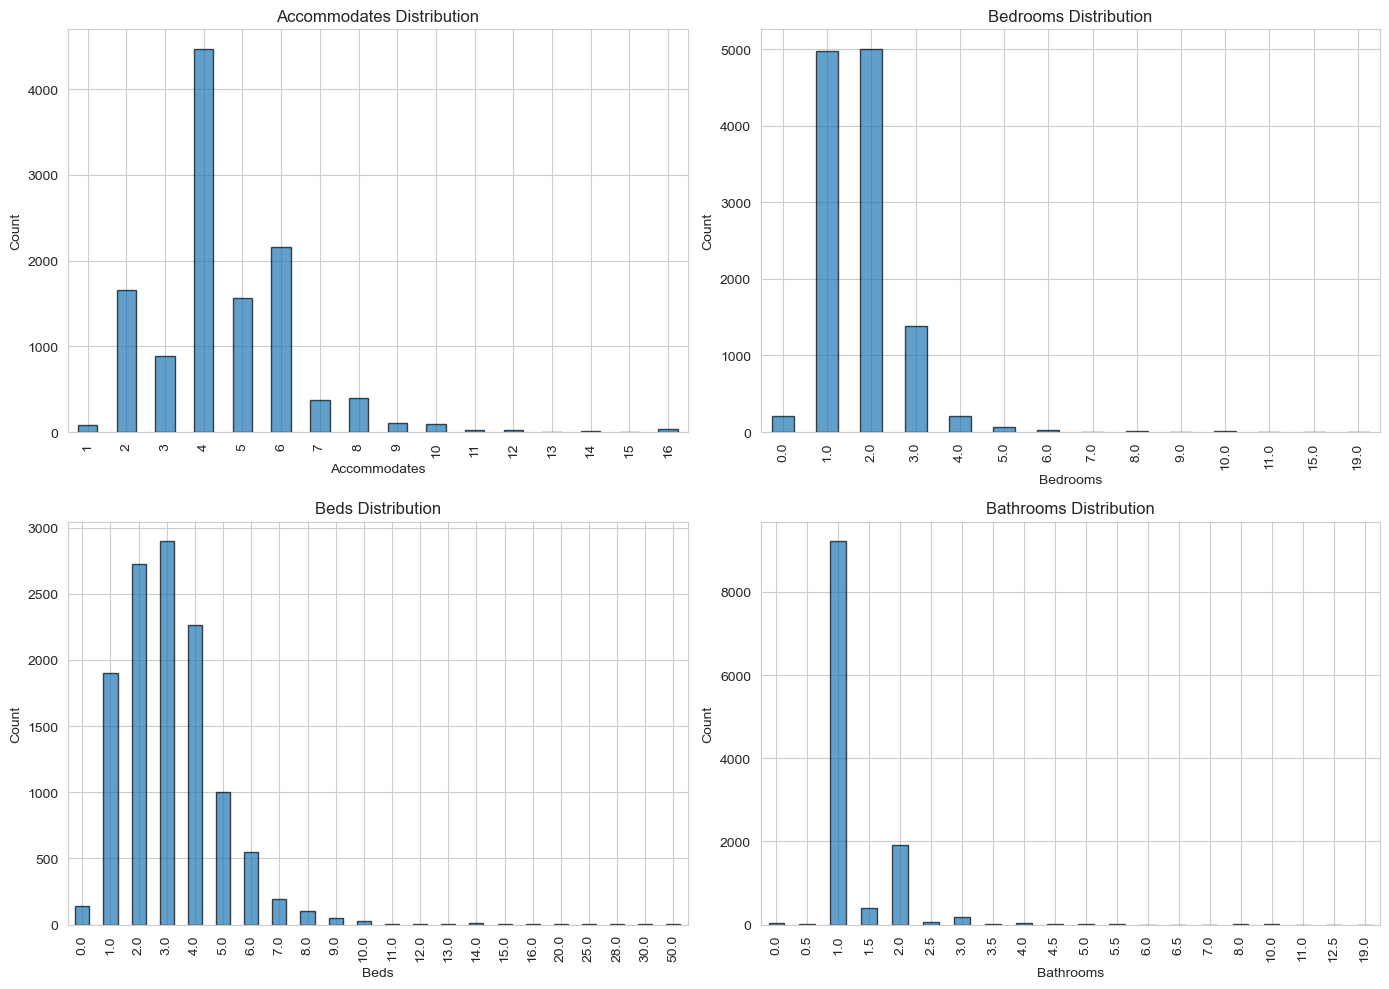


=== STRUCTURAL VARIABLE CORRELATIONS ===
              accommodates  bedrooms  beds  bathrooms
accommodates          1.00      0.70  0.73       0.52
bedrooms              0.70      1.00  0.67       0.58
beds                  0.73      0.67  1.00       0.48
bathrooms             0.52      0.58  0.48       1.00


In [ ]:
# Structural variables: bedrooms, beds, bathrooms
print("=== STRUCTURAL VARIABLES ===")
structural_vars = ['accommodates', 'bedrooms', 'beds', 'bathrooms']
print(df[structural_vars].describe().round(2))

# Distribution plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(structural_vars):
    ax = axes[i // 2][i % 2]
    df[col].value_counts().sort_index().plot(kind='bar', ax=ax, edgecolor='black', alpha=0.7)
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.set_ylabel('Count')
    ax.set_title(f'{col.replace("_", " ").title()} Distribution')

plt.tight_layout()
plt.show()

# Correlations between structural variables
print("\n=== STRUCTURAL VARIABLE CORRELATIONS ===")
print(df[structural_vars].corr().round(2))

=== REVIEW SCORES RATING ===
count    11904.000000
mean         4.775717
std          0.343340
min          1.000000
25%          4.697500
50%          4.890000
75%          5.000000
max          5.000000
Name: review_scores_rating, dtype: float64


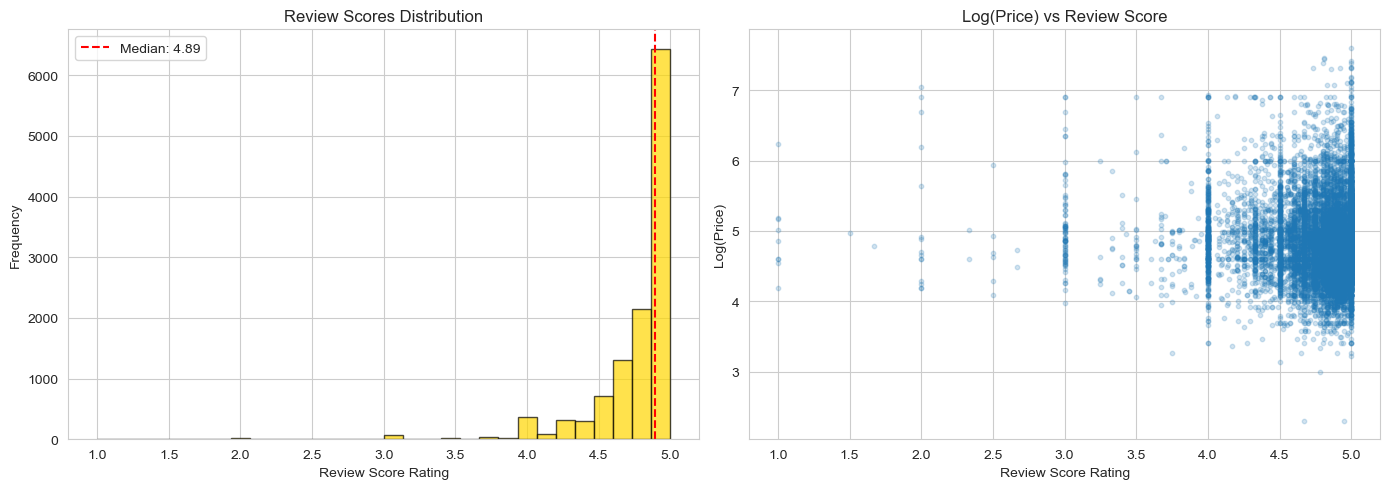

In [ ]:
# Review scores rating
print("=== REVIEW SCORES RATING ===")
print(df['review_scores_rating'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rating distribution
axes[0].hist(df['review_scores_rating'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='gold')
axes[0].axvline(df['review_scores_rating'].median(), color='red', linestyle='--', 
                label=f'Median: {df["review_scores_rating"].median():.2f}')
axes[0].set_xlabel('Review Score Rating')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Review Scores Distribution')
axes[0].legend()

# Rating vs Price
axes[1].scatter(df['review_scores_rating'], df['log_price'], alpha=0.2, s=10)
axes[1].set_xlabel('Review Score Rating')
axes[1].set_ylabel('Log(Price)')
axes[1].set_title('Log(Price) vs Review Score')

plt.tight_layout()
plt.show()

=== SUPERHOST ANALYSIS ===
Superhost: 3766 (31.6%)
Non-Superhost: 8138 (68.4%)

=== PRICE BY SUPERHOST STATUS ===
                 mean  median  count
Non-Superhost  160.30   126.0   8138
Superhost      150.28   116.0   3766


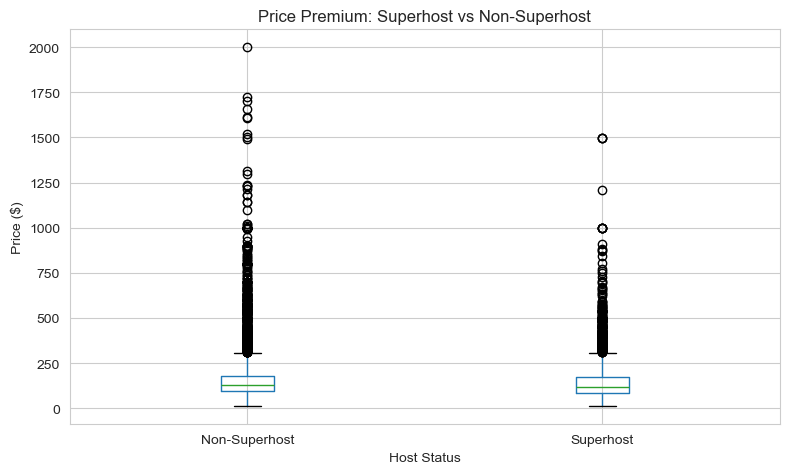

In [ ]:
# Host is Superhost analysis
print("=== SUPERHOST ANALYSIS ===")
superhost_counts = df['host_is_superhost'].value_counts()
print(f"Superhost: {superhost_counts.get(1, 0)} ({superhost_counts.get(1, 0)/len(df)*100:.1f}%)")
print(f"Non-Superhost: {superhost_counts.get(0, 0)} ({superhost_counts.get(0, 0)/len(df)*100:.1f}%)")

# Superhost price premium
print("\n=== PRICE BY SUPERHOST STATUS ===")
superhost_price = df.groupby('host_is_superhost')['price'].agg(['mean', 'median', 'count']).round(2)
superhost_price.index = ['Non-Superhost', 'Superhost']
print(superhost_price)

fig, ax = plt.subplots(figsize=(8, 5))
df.boxplot(column='price', by='host_is_superhost', ax=ax)
ax.set_xticklabels(['Non-Superhost', 'Superhost'])
ax.set_xlabel('Host Status')
ax.set_ylabel('Price ($)')
ax.set_title('Price Premium: Superhost vs Non-Superhost')
ax.figure.suptitle('')
plt.tight_layout()
plt.show()

=== AVAILABILITY_365 ===
count    11904.000000
mean       192.919355
std        114.372312
min          0.000000
25%         89.000000
50%        183.000000
75%        299.000000
max        365.000000
Name: availability_365, dtype: float64

=== MINIMUM NIGHTS ===
count    11904.000000
mean         3.281586
std          6.293556
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max        365.000000
Name: minimum_nights, dtype: float64

Listings with minimum_nights > 30 (long-term): 217 (1.8%)


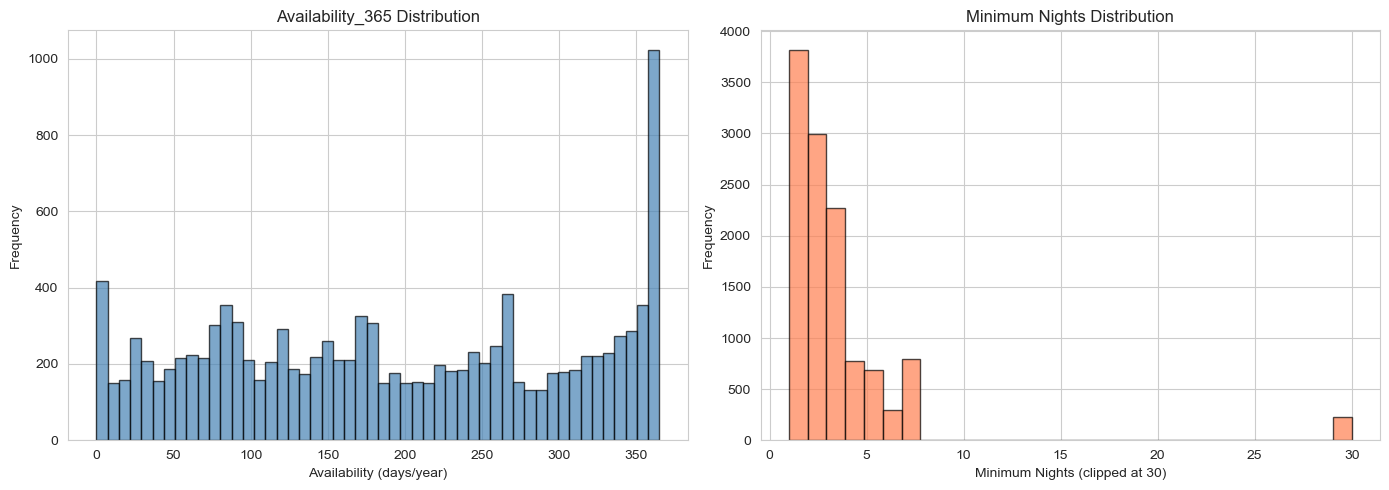

In [ ]:
# Availability and Minimum Nights
print("=== AVAILABILITY_365 ===")
print(df['availability_365'].describe())

print("\n=== MINIMUM NIGHTS ===")
print(df['minimum_nights'].describe())
print(f"\nListings with minimum_nights > 30 (long-term): {(df['minimum_nights'] > 30).sum()} ({(df['minimum_nights'] > 30).mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['availability_365'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Availability (days/year)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Availability_365 Distribution')

# Minimum nights - clip at 30 for visibility
min_nights_clipped = df['minimum_nights'].clip(upper=30)
axes[1].hist(min_nights_clipped, bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_xlabel('Minimum Nights (clipped at 30)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Minimum Nights Distribution')

plt.tight_layout()
plt.show()

## 5. Spatial Distribution Analysis

GeoDataFrame created with 11904 points


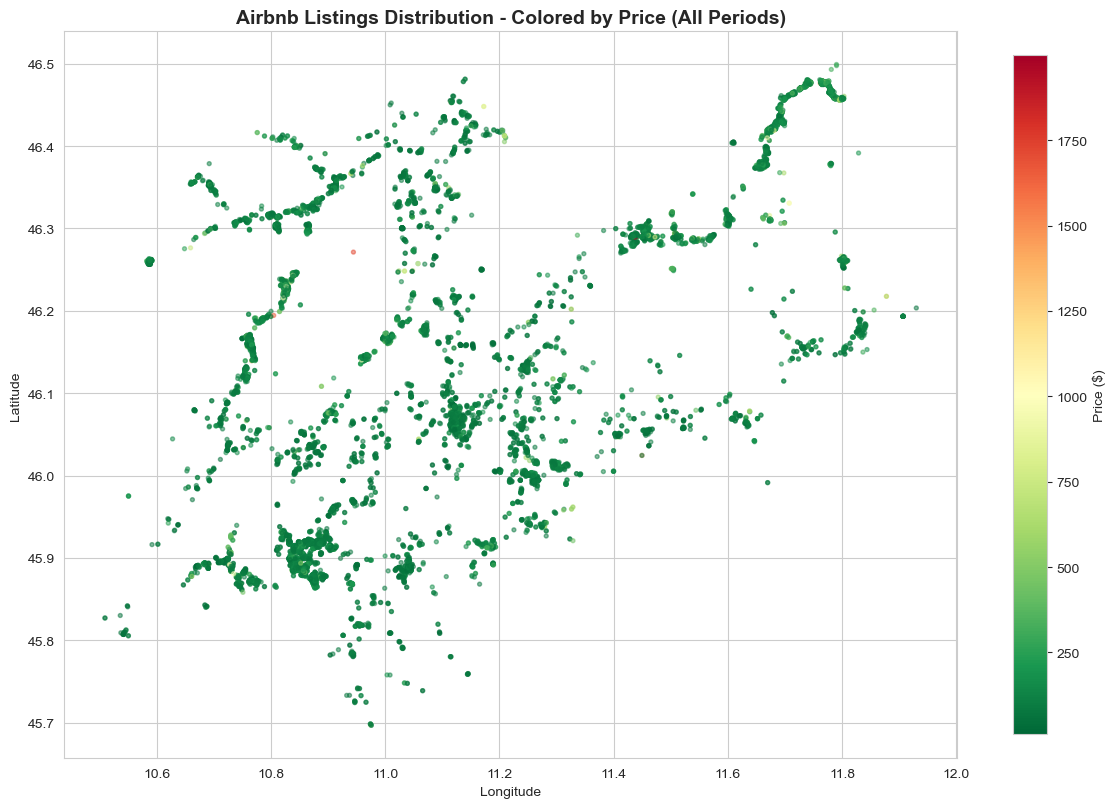

In [ ]:
# Convert to GeoDataFrame for mapping
gdf = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df.long, df.lat),
    crs='EPSG:4326'
)
print(f"GeoDataFrame created with {len(gdf)} points")

# Map of all listings colored by price
fig, ax = plt.subplots(figsize=(12, 10))
gdf.plot(
    column='price',
    cmap='RdYlGn_r',
    legend=True,
    markersize=8,
    alpha=0.5,
    ax=ax,
    legend_kwds={'label': 'Price ($)', 'shrink': 0.7}
)
ax.set_title('Airbnb Listings Distribution - Colored by Price (All Periods)', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

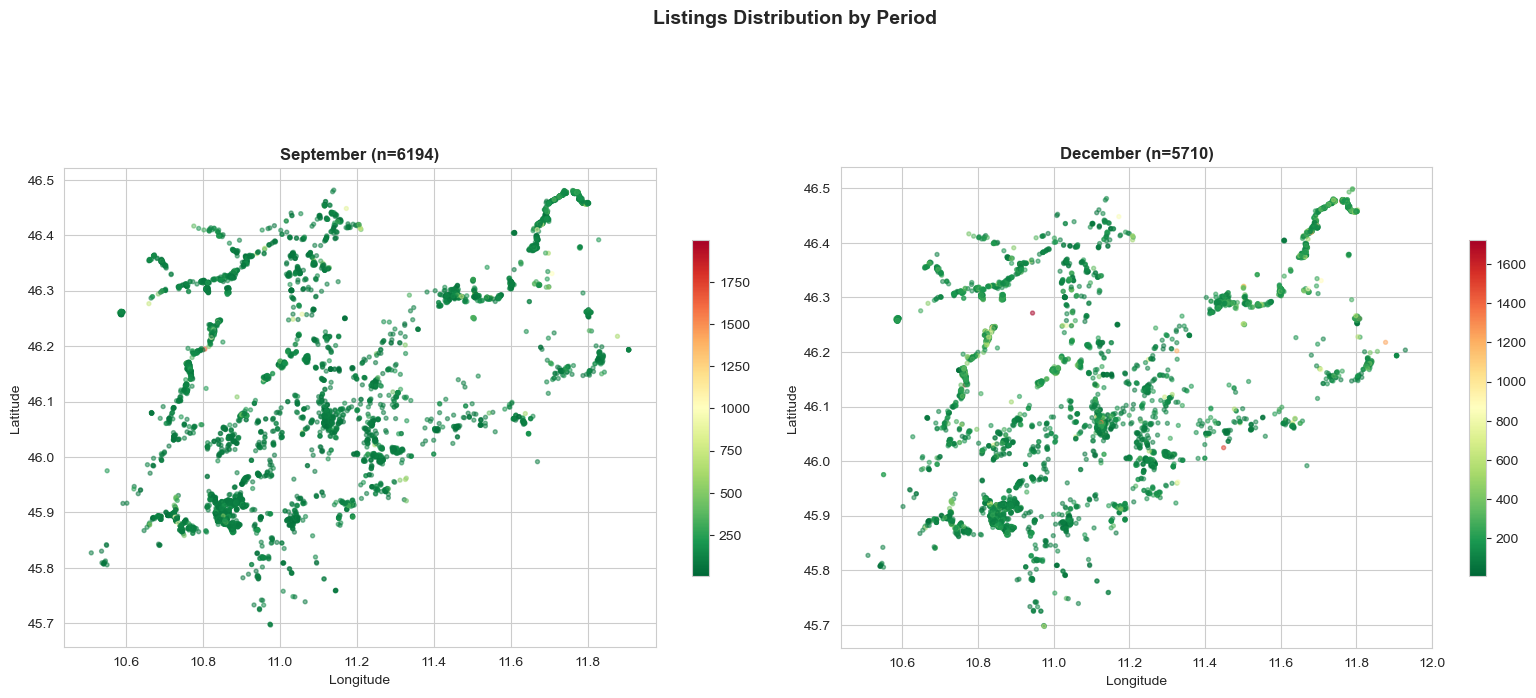

In [ ]:
# Map by period (spatial coverage comparison)
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for i, period in enumerate(periods_present):
    gdf_p = gdf[gdf['period'] == period]
    gdf_p.plot(
        column='price',
        cmap='RdYlGn_r',
        legend=True,
        markersize=8,
        alpha=0.5,
        ax=axes[i],
        legend_kwds={'shrink': 0.5}
    )
    axes[i].set_title(f'{period.title()} (n={len(gdf_p)})', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Longitude')
    axes[i].set_ylabel('Latitude')

# Hide unused subplots if fewer than 4 periods
for j in range(len(periods_present), 4):
    axes[j].set_visible(False)

plt.suptitle('Listings Distribution by Period', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

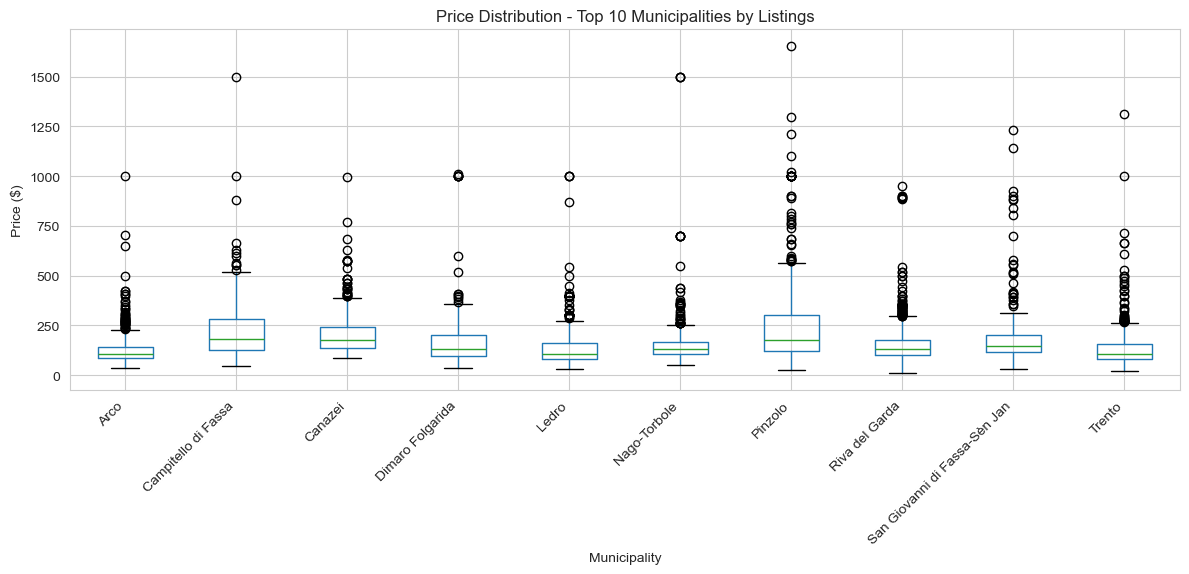

In [ ]:
# Price by municipality (top 10)
top_10_municipalities = df['municipality'].value_counts().head(10).index
df_top10 = df[df['municipality'].isin(top_10_municipalities)]

plt.figure(figsize=(12, 6))
df_top10.boxplot(column='price', by='municipality', ax=plt.gca())
plt.xlabel('Municipality')
plt.ylabel('Price ($)')
plt.title('Price Distribution - Top 10 Municipalities by Listings')
plt.suptitle('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Distance statistics
df_clean = df.copy()
for col in distance_cols:
    df_clean.loc[df_clean[col] == 99999, col] = np.nan

print("=== DISTANCE STATISTICS (meters) ===")
distance_stats = df_clean[distance_cols].describe().T
distance_stats['mean_km'] = distance_stats['mean'] / 1000
distance_stats['median_km'] = distance_stats['50%'] / 1000
print(distance_stats[['mean_km', 'median_km', 'min', 'max']].round(2))

=== DISTANCE STATISTICS (meters) ===
                  mean_km  median_km    min       max
dist_ski             5.94       4.44   0.40  22667.05
dist_lake            0.73       0.46   0.00   4931.73
dist_park            1.29       0.57   0.00  12195.77
dist_station         7.95       5.86  42.38  31089.14
dist_bus             0.26       0.17   0.91   7206.35
dist_center          2.90       2.48  63.77  13588.36
dist_supermarket     0.63       0.35   0.00   8404.60
dist_restaurant      0.38       0.23   0.00   6598.02
dist_bar             0.60       0.30   0.00   7672.60
dist_pharmacy        1.13       0.56   2.78  10540.44
dist_castle          5.73       3.67   0.00  22956.38
dist_museum          2.46       1.95   0.05  12907.89


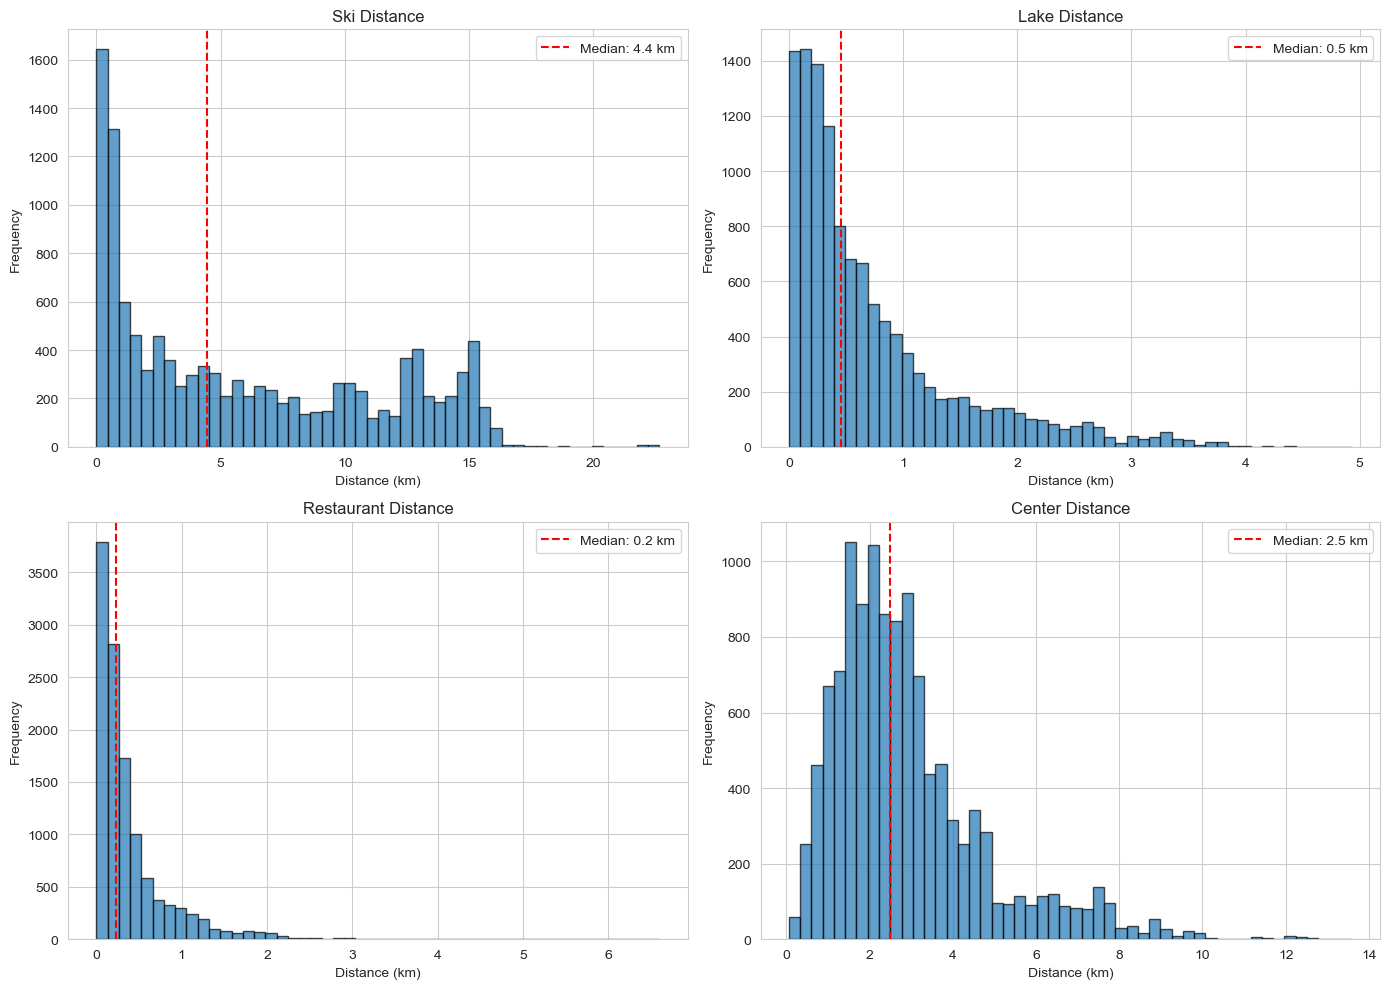

In [ ]:
# Distribution of key distances
key_distances = ['dist_ski', 'dist_lake', 'dist_restaurant', 'dist_center']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(key_distances):
    data = df_clean[col].dropna() / 1000
    axes[i].hist(data, bins=50, edgecolor='black', alpha=0.7)
    axes[i].axvline(data.median(), color='red', linestyle='--', label=f'Median: {data.median():.1f} km')
    axes[i].set_xlabel('Distance (km)')
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'{col.replace("dist_", "").replace("_", " ").title()} Distance')
    axes[i].legend()

plt.tight_layout()
plt.show()

## 6. Correlation Analysis

In [ ]:
# Correlation with price - ALL variables (old + new)
numeric_cols = ['price', 'accommodates', 'bedrooms', 'beds', 'bathrooms',
                'n_reviews', 'review_scores_rating', 'host_is_superhost',
                'availability_365', 'minimum_nights'] + distance_cols

corr_data = df_clean[numeric_cols]
price_corr = corr_data.corr()['price'].drop('price').sort_values(ascending=False)

print("=== CORRELATION WITH PRICE (all variables) ===")
print(price_corr.round(3))

=== CORRELATION WITH PRICE (all variables) ===
accommodates            0.326
bathrooms               0.290
bedrooms                0.268
beds                    0.246
dist_castle             0.194
dist_station            0.112
dist_park               0.056
dist_lake               0.056
dist_supermarket        0.041
dist_bus                0.041
minimum_nights          0.033
dist_pharmacy           0.033
dist_center             0.016
dist_bar                0.005
dist_museum            -0.007
dist_restaurant        -0.014
review_scores_rating   -0.026
host_is_superhost      -0.036
availability_365       -0.044
n_reviews              -0.120
dist_ski               -0.154
Name: price, dtype: float64


## 7. Summary for R Spatial Regression

In [ ]:
print("="*70)
print("SUMMARY FOR SPATIAL REGRESSION IN R")
print("="*70)

print(f"\n📊 Dataset Overview")
print(f"   Total listings: {len(df):,}")
print(f"   Periods: {', '.join(periods_present)} (n={len(periods_present)})")
print(f"   Municipalities: {df['municipality'].nunique()}")
print(f"   Property types: {df['property_type'].nunique()}")

print(f"\n💰 Price Summary")
print(f"   Range: ${df['price'].min():.0f} - ${df['price'].max():.0f}")
print(f"   Median: ${df['price'].median():.0f}")
print(f"   Mean: ${df['price'].mean():.0f}")

print(f"\n🏠 Structural Variables (NEW)")
print(f"   Bedrooms: {df['bedrooms'].min():.0f}-{df['bedrooms'].max():.0f} (median: {df['bedrooms'].median():.0f})")
print(f"   Beds: {df['beds'].min():.0f}-{df['beds'].max():.0f} (median: {df['beds'].median():.0f})")
print(f"   Bathrooms: {df['bathrooms'].min():.1f}-{df['bathrooms'].max():.1f} (median: {df['bathrooms'].median():.1f})")

print(f"\n⭐ Quality & Host Variables (NEW)")
print(f"   Review Score: {df['review_scores_rating'].mean():.2f} (median: {df['review_scores_rating'].median():.2f})")
print(f"   Superhosts: {(df['host_is_superhost']==1).sum()} ({(df['host_is_superhost']==1).mean()*100:.1f}%)")
print(f"   Avg availability: {df['availability_365'].mean():.0f} days/year")
print(f"   Median minimum nights: {df['minimum_nights'].median():.0f}")

print(f"\n📍 Top 5 Municipalities (by listings)")
for i, (muni, count) in enumerate(df['municipality'].value_counts().head(5).items(), 1):
    avg_price = df[df['municipality']==muni]['price'].mean()
    print(f"   {i}. {muni}: {count} listings (avg ${avg_price:.0f})")

print(f"\n🗺️ Spatial Variables")
print(f"   Distance variables: {len(distance_cols)}")
print(f"   Key distances (median km):")
for dist in ['dist_center', 'dist_ski', 'dist_lake', 'dist_restaurant']:
    median_km = df_clean[dist].median() / 1000
    print(f"      {dist.replace('dist_', '')}: {median_km:.2f} km")

print(f"\n🔗 Variables for R Spatial Regression:")
print(f"   Dependent: log_price")
print(f"   Structural: room_type, property_type, accommodates, bedrooms, beds, bathrooms")
print(f"   Reputational: n_reviews, review_scores_rating")
print(f"   Host: host_is_superhost, availability_365, minimum_nights")
print(f"   Spatial: {len(distance_cols)} distance variables")
print(f"   Period: period (factor for multi-period analysis)")
print(f"   Coordinates: lat, long (for KNN spatial weights)")

print(f"\n✅ Dataset ready for R!")
print(f"   File: datasets/trentino_listings_maps.csv")
print(f"   Total variables: {df.shape[1]}")

SUMMARY FOR SPATIAL REGRESSION IN R

📊 Dataset Overview
   Total listings: 11,904
   Periods: september, december (n=2)
   Municipalities: 161
   Property types: 56

💰 Price Summary
   Range: $10 - $1999
   Median: $123
   Mean: $157

🏠 Structural Variables (NEW)
   Bedrooms: 0-19 (median: 2)
   Beds: 0-50 (median: 3)
   Bathrooms: 0.0-19.0 (median: 1.0)

⭐ Quality & Host Variables (NEW)
   Review Score: 4.78 (median: 4.89)
   Superhosts: 3766 (31.6%)
   Avg availability: 193 days/year
   Median minimum nights: 2

📍 Top 5 Municipalities (by listings)
   1. Riva del Garda: 1150 listings (avg $154)
   2. Trento: 780 listings (avg $130)
   3. Arco: 730 listings (avg $125)
   4. Pinzolo: 493 listings (avg $256)
   5. Ledro: 475 listings (avg $151)

🗺️ Spatial Variables
   Distance variables: 12
   Key distances (median km):
      center: 2.48 km
      ski: 4.44 km
      lake: 0.46 km
      restaurant: 0.23 km

🔗 Variables for R Spatial Regression:
   Dependent: log_price
   Structural: roo

In [ ]:
# Top 10 most expensive listings
print("\n" + "="*70)
print("TOP 10 MOST EXPENSIVE LISTINGS")
print("="*70)

expensive = df.nlargest(10, 'price')[
    ['id', 'price', 'period', 'municipality', 'property_type', 'room_type', 
     'accommodates', 'bedrooms', 'bathrooms', 'review_scores_rating', 'host_is_superhost']
]
print(expensive.to_string(index=False))


TOP 10 MOST EXPENSIVE LISTINGS
                id  price    period        municipality      property_type       room_type  accommodates  bedrooms  bathrooms  review_scores_rating  host_is_superhost
980854821512800143 1999.0 september     Ville di Fiemme Entire rental unit Entire home/apt             6       2.0        1.0                  5.00                0.0
          36836400 1724.0  december     Ville d'Anaunia Entire rental unit Entire home/apt             5       0.0        1.0                  4.81                0.0
           1482326 1700.0 september     Ville di Fiemme       Entire condo Entire home/apt             6       2.0        1.0                  4.81                0.0
758028232754996754 1655.0 september             Pinzolo      Entire chalet Entire home/apt            14       9.0       10.0                  5.00                0.0
          43541968 1612.0  december            Giustino       Entire cabin Entire home/apt            16       8.0       10.0        

In [ ]:
# Key findings summary
print("\n" + "="*70)
print("KEY FINDINGS FOR THESIS")
print("="*70)

print("\n🔍 Strongest Price Correlations:")
top_corr = price_corr.head(5)
for var, corr in top_corr.items():
    print(f"   {var.replace('_', ' ').title()}: {corr:+.3f}")

print("\n📉 Most Negative Correlations:")
bottom_corr = price_corr.tail(5)
for var, corr in bottom_corr.items():
    print(f"   {var.replace('_', ' ').replace('dist ', 'Distance to ').title()}: {corr:+.3f}")

print("\n🎯 Hypothesis Tests for R:")
print("   H1: Superhost premium exists → Test host_is_superhost coefficient")
print("   H2: Quality premium exists → Test review_scores_rating coefficient")
print("   H3: Ski proximity matters (winter) → Test dist_ski by period interaction")
print("   H4: Urban center premium → Test dist_center coefficient")
print("   H5: Structural elasticity → Test bedrooms/bathrooms coefficients")

print("\n" + "="*70)


KEY FINDINGS FOR THESIS

🔍 Strongest Price Correlations:
   Accommodates: +0.326
   Bathrooms: +0.290
   Bedrooms: +0.268
   Beds: +0.246
   Dist Castle: +0.194

📉 Most Negative Correlations:
   Review Scores Rating: -0.026
   Host Is Superhost: -0.036
   Availability 365: -0.044
   N Reviews: -0.120
   Distance To Ski: -0.154

🎯 Hypothesis Tests for R:
   H1: Superhost premium exists → Test host_is_superhost coefficient
   H2: Quality premium exists → Test review_scores_rating coefficient
   H3: Ski proximity matters (winter) → Test dist_ski by period interaction
   H4: Urban center premium → Test dist_center coefficient
   H5: Structural elasticity → Test bedrooms/bathrooms coefficients

